In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms.functional as TF
from torchvision import transforms
from torchvision.datasets import Kitti
import torchvision.models as models
from torchvision.ops import nms

import os, copy, time
import numpy as np
import random
from typing import Dict, List, Tuple, Optional, Callable
import argparse
from tqdm import tqdm

import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

In [2]:
DATA_DIR = os.path.join(os.getcwd(), "data")  # 여기 아래에 Kitti/raw/... 구조가 생김

transform = transforms.Compose([
    transforms.ToTensor(),   # PIL → torch.Tensor [0, 1]
])

def target_transform(target):
    # 입력된 label 정보를 변환하기 위한 기능
    # target: list[dict], 각 dict에 keys: type, truncated, occluded, alpha, bbox, dimensions, location, rotation_y
    # 예: 여기서는 일단 그대로 반환
    return target

train_dataset = Kitti(
    root=DATA_DIR,
    train=True,
    transform=transform,
    target_transform=target_transform,  # 필요 없으면 None
    download=True,                      # 한 번만 True면 됨
)
test_dataset = Kitti(
    root=DATA_DIR,
    train=False,
    transform=transform,
    target_transform=None,
    download=False,
)
print("Train data samples: ", len(train_dataset))
print("Test data samples: ", len(test_dataset))

Train data samples:  7481
Test data samples:  7518


In [3]:
idx = random.randint(0, len(train_dataset)-1) # 한 장의 샘플 데이터를 무작위로 추출
sample = train_dataset[idx]
sample # 길이 2짜리 tuple, 0: 데이터, 1: label dict들이 들어있는 list

(tensor([[[0.3725, 0.3294, 0.2588,  ..., 0.0667, 0.0667, 0.0549],
          [0.4000, 0.3961, 0.3294,  ..., 0.0902, 0.0824, 0.0627],
          [0.0824, 0.1098, 0.1255,  ..., 0.0902, 0.0824, 0.0784],
          ...,
          [0.0667, 0.0667, 0.0667,  ..., 0.6667, 0.7333, 0.7843],
          [0.0667, 0.0667, 0.0667,  ..., 0.6549, 0.7137, 0.7686],
          [0.0706, 0.0706, 0.0824,  ..., 0.5569, 0.6000, 0.6510]],
 
         [[0.2706, 0.3059, 0.2667,  ..., 0.0706, 0.0706, 0.0549],
          [0.1882, 0.2627, 0.2863,  ..., 0.0667, 0.0667, 0.0588],
          [0.1569, 0.1529, 0.1647,  ..., 0.0824, 0.0863, 0.0863],
          ...,
          [0.0824, 0.0824, 0.0902,  ..., 0.7333, 0.7686, 0.7412],
          [0.0902, 0.0941, 0.0941,  ..., 0.6588, 0.7255, 0.7137],
          [0.0941, 0.1020, 0.1020,  ..., 0.5529, 0.5765, 0.6118]],
 
         [[0.1412, 0.1608, 0.1608,  ..., 0.0353, 0.0314, 0.0314],
          [0.0941, 0.1490, 0.1608,  ..., 0.0353, 0.0314, 0.0353],
          [0.0863, 0.1412, 0.1686,  ...,

Image idx:  3203
------ Example ------
torch.Size([3, 375, 1242])
(1242, 375)


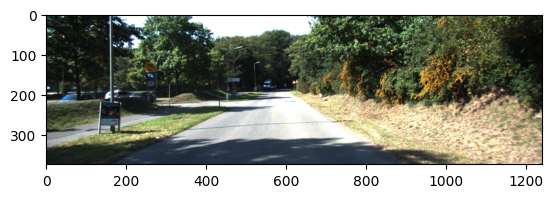

(375, 1242, 3)
['type', 'truncated', 'occluded', 'alpha', 'bbox', 'dimensions', 'location', 'rotation_y']

------ objects ------
{'type': 'Car', 'truncated': 0.0, 'occluded': 1, 'alpha': -1.17, 'bbox': [205.53, 193.16, 276.93, 224.9], 'dimensions': [1.42, 1.7, 4.14], 'location': [-18.55, 2.49, 36.44], 'rotation_y': -1.64}
{'type': 'Car', 'truncated': 0.0, 'occluded': 1, 'alpha': -1.1, 'bbox': [145.1, 191.73, 223.66, 225.63], 'dimensions': [1.52, 1.71, 4.11], 'location': [-21.31, 2.51, 36.26], 'rotation_y': -1.63}
{'type': 'Car', 'truncated': 0.0, 'occluded': 1, 'alpha': 2.15, 'bbox': [10.49, 196.62, 132.16, 246.6], 'dimensions': [1.42, 1.55, 3.45], 'location': [-17.56, 2.25, 23.67], 'rotation_y': 1.52}
{'type': 'DontCare', 'truncated': -1.0, 'occluded': -1, 'alpha': -10.0, 'bbox': [539.32, 165.65, 583.6, 194.41], 'dimensions': [-1.0, -1.0, -1.0], 'location': [-1000.0, -1000.0, -1000.0], 'rotation_y': -10.0}


In [4]:
print('Image idx: ', idx)
print("------ Example ------")
img = sample[0]
print(img.shape)
img = TF.to_pil_image(img)
print(img.size)

plt.imshow(img)
plt.show()
print(np.shape(img))
print(list(sample[1][0].keys()))

print("\n------ objects ------")
objs = sample[1]
for obj in objs:
    print(obj)

In [5]:
# 이미지 위에 bounding box 그려서 보여주는 함수
def visualize_bbox(input_img, objs):
    input_img = copy.deepcopy(input_img)
    draw = ImageDraw.Draw(input_img)

    for obj in objs:
        # bbox 좌표 (x_min, y_min, x_max, y_max)
        h, w, _ = np.shape(input_img) # 이미지 자체의 shape
        x_min, y_min, x_max, y_max = obj['bbox']

        # bbox 그리기
        draw.rectangle([x_min, y_min, x_max, y_max], outline=(255,0,0), width=2)

    return input_img

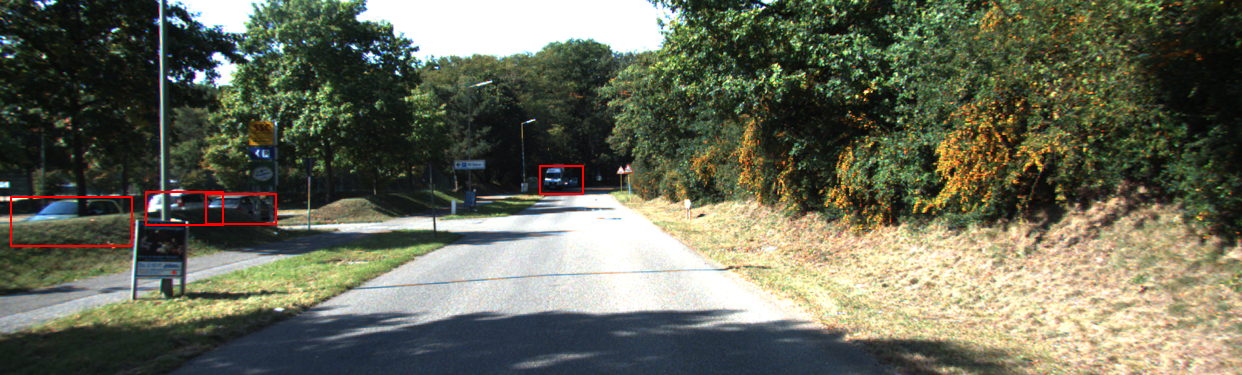

In [6]:
visualize_bbox(img, objs)

데이터 준비 (KITTI 데이터를 학습에 맞는 형태로 변환)

In [7]:
class KITTIDataset(Dataset):
    """
    KIITI 객체 탐지 데이터셋
    args: 
        img_dir: 이미지 디렉터리 경로
        label_dir: 라벨 디렉터리 경로
        classes: 사용할 클래스 리스트 (None이면 모든 클래스 사용)
        exclude_dontcare: DontCare 객체 제외 여부
    """

    # KIITI 데이터셋의 모든 클래스
    ALL_CLASSES = [
        'Car', 'Van', 'Truck', 'Pedestrian', 'Person_sitting',
        'Cyclist', 'Tram', 'Misc', 'DontCare'
    ]
    
    def __init__(self, img_dir:str, label_dir:str, classes:Optional[List[str]] = None, exclude_dontcare:bool=True):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.exclude_doncare = exclude_dontcare

        # 사용할 클래스 설정
        if classes is None:
            self.classes = [c for c in self.ALL_CLASSES if c != "DontCare"]
        else:
            self.classes = classes

        # 클래스명 -> 인덱스 매핑 (0부터 시작)
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}
        self.idx_to_class = {idx: cls_name for cls_name, idx in self.class_to_idx.items()}

        # 이미지 파일 리스트 가져오기
        self.img_files = self._get_img_files()

        print(f"KIITIDataset 초기화 완료: ")
        print(f"  - 이미지 개수: {len(self.img_files)}")
        print(f"  - 클래스 개수: {len(self.classes)}")
        print(f"  - 클래스: {self.classes}")

    def _get_img_files(self) -> List[str]:
        """이미지 파일 목록을 가져오고 검증"""
        img_files = []

        # 이미지 디렉터리의 모든 png 파일 찾기
        for fname in sorted(os.listdir(self.img_dir)):
            if fname.endswith(".png") or fname.endswith(".jpg"):
                img_path = os.path.join(self.img_dir, fname)
                label_path = os.path.join(self.label_dir, fname.replace(".png", ".txt").replace('.jpg', '.txt'))

                # 이미지와 레이블 모두 존재하는지 확인
                if os.path.exists(img_path) and os.path.exists(label_path):
                    img_files.append(fname)
                else:
                    print(f"warning.. {fname}의 레이블 파일이 없습니다..")

        return img_files
    
    def _parse_label(self, label_path: str) -> Tuple[np.ndarray, np.ndarray]:
        """라벨 파일을 파싱하여, bbox와 클래스 정보 추출
        return:
            boxes: (N, 4) numpy array of [x_min, y_min, x_max, y_max]
            labels: (N, ) numpy array of class indices
        """
        boxes = []
        labels = []

        if not os.path.exists(label_path):
            return np.zeors((0, 4), dtype=np.float32), np.zeros((0,), dtype=np.int64)
        
        with open(label_path, 'r') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                
                parts = line.split()
                if len(parts) < 15: # 라벨에 15개 요소가 있으므로
                    continue

                class_name = parts[0]

                # DontCare 제외 옵션 처리
                if self.exclude_doncare and class_name == "DontCare":
                    continue

                # 사용할 클래스에 포함되지 않으면 스킵
                if class_name not in self.classes:
                    continue

                # BBOX 좌표 (2D bbox)
                try:
                    bbox = [float(parts[4]), float(parts[5]), float(parts[6]), float(parts[7])]

                    # 유효한 bbox인지 확인
                    if bbox[2] > bbox[0] and bbox[3] > bbox[1]:
                        boxes.append(bbox)
                        labels.append(self.class_to_idx[class_name])
                except (ValueError, IndexError):
                    continue

        if len(boxes) == 0:
            return np.zeros((0,4), dtype=np.float32), np.zeros((0,), dtype=np.int64)
        
        return np.array(boxes, dtype=np.float32), np.array(labels, dtype=np.int64)
    
    def __len__(self):
        """데이터셋의 크기를 반환"""
        return len(self.img_files)
    
    def __getitem__(self, idx:int) -> Dict:
        """
        idx에 해당하는 샘플을 반환

        return: 
            dict: {
                'img': PIL.Image,
                'boxes': np.ndarray (N, 4),
                'labels': np.ndarray (N,),
                'img_id': str
            }
        """

        # 파일명 가져오기
        fname = self.img_files[idx]
        img_path = os.path.join(self.img_dir, fname)
        label_path = os.path.join(self.label_dir, fname.replace('.png', '.txt').replace('.jpg', '.txt'))

        # 이미지 로드
        img = Image.open(img_path).convert('RGB')

        # 라벨 파싱
        boxes, labels = self._parse_label(label_path)

        # 결과 딕셔너리 생성
        target = {
            'img': img,
            'boxes': boxes,
            'labels': labels,
            'img_id': fname.replace('.png', '').replace('.jpg', '')
        }
        return target   

    def get_class_name(self, idx:int) -> str:
        """클래스 인덱스 반환"""
        return self.idx_to_class.get(idx, "Unknown")
    
    def get_num_classes(self) -> int:
        "클래스 개수를 반환"
        return len(self.classes)

In [8]:
a = np.zeros((0,4))
print(a)
print(a.shape)
print(a.size)

[]
(0, 4)
0


In [9]:
class RandomHorizontalFlip:
    """랜덤 좌우 반전 + bbox 좌표 조정"""
    def __init__(self, p=0.5):
        self.p = p
    
    def __call__(self, img, tgt):
        if random.random() < self.p:
            # 이미지가 PIL인지 Tensor인지 확인
            if isinstance(img, Image.Image):
                img = TF.hflip(img)
                w, _ = img.size
            else: # Tensor
                img =  TF.hflip(img)
                _, _, w = img.shape
            
            # bbox 좌표 변환
            boxes = tgt['boxes'].copy()
            if len(boxes) > 0:
                # x_min, x_max
                # 예: 1.5, 3.5, 10 -> 10-3.5 = 6.5, 10-1.5 = 8.5
                boxes[:, [0, 2]] = w - boxes[:, [2, 0]]
                tgt['boxes'] = boxes
        
        return img, tgt

In [10]:
a = torch.arange(0, 12).reshape(3, 4)
print(a[:, [0,2]])
print(a[:, [2,0]])

tensor([[ 0,  2],
        [ 4,  6],
        [ 8, 10]])
tensor([[ 2,  0],
        [ 6,  4],
        [10,  8]])


In [11]:
class ColorJitter:
    """ 색상 변환: 밝기, 대비, 채도, 색조 조정 """
    def __init__(self, br=0.2, ct=0.2, st=0.2, hue=0.1):
        self.br = br
        self.ct = ct
        self.st = st
        self.hue = hue
    
    def __call__(self, img, tgt):
        # PIL Image에만 적용 (Tensor 이전에 적용되어야 함)
        if isinstance(img, Image.Image):
            if self.br > 0:
                br_factor = random.uniform(1 - self.br, 1 + self.br)
                img = TF.adjust_brightness(img, br_factor)
            if self.ct > 0:
                ct_factor = random.uniform(1 - self.ct, 1 + self.ct)
                img = TF.adjust_contrast(img, ct_factor)
            if self.st > 0:
                st_factor = random.uniform(1 - self.st, 1 + self.st)
                img = TF.adjust_saturation(img, st_factor)
            if self.hue > 0:
                hue_factor = random.uniform(-self.hue, self.hue)
                img = TF.adjust_hue(img, hue_factor)
        return img, tgt

In [12]:
class Resize:
    """ 고정 크기로 리사이즈 + bbox 스케일링 """
    def __init__(self, size: Tuple[int, int]):
        """ Args: 
                size: (height, width) tuple
        """
        self.size = size # (H, W)
    
    def __call__(self, img, tgt):
        # 원본 크기
        if isinstance(img, Image.Image):
            origin_w, origin_h = img.size
            img  = TF.resize(img, self.size)
        else:
            _, origin_h, origin_w = img.shape
            img = TF.resize(img, self.size)
        
        # 스케일 계산
        new_h, new_w = self.size
        scale_y = new_h / origin_h
        scale_x = new_w / origin_w

        # bbox 스케일링
        boxes = tgt['boxes'].copy()
        if len(boxes) > 0:
            boxes[:, 0] *= scale_x # x_min
            boxes[:, 1] *= scale_y # y_min
            boxes[:, 2] *= scale_x # x_max
            boxes[:, 3] *= scale_y # y_max
            tgt['boxes'] = boxes
        
        return img, tgt

In [13]:
class RandomCrop:
    """ 랜덤 크롭 + bbox 클리핑 및 유효성 검증 """

    def __init__(self, size: Tuple[int, int], min_area_ratio=0.3):
        """ Args: 
                size: (height, width) 크롭 크기
                min_area_ratio: 크롭 후 최소 면적 비율 (원본 대비)
        """
        self.size = size
        self.min_area_ratio = min_area_ratio
    
    def __call__(self, img, tgt):
        # 원본 크기
        if isinstance(img, Image.Image):
            origin_w, origin_h = img.size
        else:
            _, origin_h, origin_w = img.shape
        
        crop_h, crop_w = self.size

        # 이미지가 크롭 크기보다 작으면 패딩
        if origin_h < crop_h or origin_w < crop_w:
            # 패딩 없이 리사이즈로 처리
            resize_tr = Resize(self.size)
            return resize_tr(img, tgt)

        # 랜덤 크롭 위치
        top = random.randint(0, origin_h - crop_h)
        left = random.randint(0, origin_w, crop_w)

        # 이미지 크롭
        if isinstance(img, Image.Image):
            img = TF.crop(img, top, left, crop_h, crop_w)
        else:
            img = TF.crop(img, top, left, crop_h, crop_w)

        # bbox 조정
        boxes = tgt['boxes'].copy()
        labels = tgt['labels'].copy()

        if len(boxes) > 0:
            # 크롭 영역으로 좌표 변환
            boxes[:, 0] -= left # x_min
            boxes[:, 1] -= top # y_min
            boxes[:, 2] -= left # x_max
            boxes[:, 3] -= top # y_max

            # 크롭 영역 내로 클리핑
            boxes[:, 0] = np.clip(boxes[:, 0], 0, crop_w)
            boxes[:, 1] = np.clip(boxes[:, 1], 0, crop_h)
            boxes[:, 2] = np.clip(boxes[:, 2], 0, crop_w)
            boxes[:, 3] = np.clip(boxes[:, 3], 0, crop_h)

            # 유효한 bbox만 유지 (최소 면적 체크)
            areas = (boxes[:, 2] - boxes[:, 0]) *(boxes[:, 3] - boxes[:, 1])
            origin_areas = (tgt['boxes'][:, 2] - tgt['boxes'][:, 0]) * (tgt['boxes'][:, 3] - tgt['boxes'][:, 1])
            valid_mask = (boxes[:, 2] > boxes[:, 0]) & (boxes[:, 3] > boxes[:, 1]) & (areas >= origin_areas * self.min_area_ratio)
            
            boxes = boxes[valid_mask]
            labels = labels[valid_mask]
        
        tgt['boxes'] = boxes
        tgt['labels'] = labels

        return img, tgt         



In [14]:
class ToTensor:
    """ PIL 이미지를 Tensor로 변환 """
    def __call__(self, img, tgt):
        img = TF.to_tensor(img)
        return img, tgt

In [15]:
class Normalize:
    """ 이미지를 정규화 (ImageNet 평균 / 표준편차) """
    def __init__(self, mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]):
        self.mean = mean
        self.std = std
    
    def __call__(self, img, tgt):
        img = TF.normalize(img, mean=self.mean, std=self.std)
        return img, tgt

In [16]:
# 변환 요소 연결

In [17]:
class Compose:
    """ 여러 변환 순차적 적용 """
    def __init__(self, transforms: List[Callable]):
        self.transforms = transforms
    
    def __call__(self, img, tgt):
        for t in self.transforms:
            img, tgt = t(img, tgt)
        return img, tgt

In [18]:
def collate_fn(batch: List[Dict]) -> Tuple[torch.tensor, List[Dict]]:
    """ 
    배치 생성을 위한 custom collate 함수
    이미지 크기가 다를 수 있으므로 리스트로 반환
    Args: 
        batch: 샘플 리스트
    return:
        imgs: (B, C, H, W) Tensor
        tgts: 타겟 딕셔너리 리스트
    """
    imgs = []
    tgts = []

    for item in batch:
        imgs.append(item['img'])
        tgts.append({
            'boxes': torch.tensor(item['boxes'], dtype=torch.float32),
            'labels': torch.tensor(item['labels'], dtype=torch.int64),
            'img_id': item['img_id'],
        })
    
    # 이미지를 stack (모두 같은 크기여야 함)
    imgs = torch.stack(imgs, dim=0)
    return imgs, tgts

In [19]:
class TransformedDataset:
    """ Transform을 적용하는 데이터셋 래퍼 """

    def __init__(self, dataset:KITTIDataset, transform: Optional[Callable]=None):
        self.dataset = dataset
        self.transform = transform
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        sample = self.dataset[idx]
        img = sample['img']
        tgt = {
            'boxes': sample['boxes'],
            'labels': sample['labels'],
            'img_id': sample['img_id'] 
        }

        if self.transform is not None:
            img, tgt = self.transform(img, tgt)
        
        return {
            'img': img,
            'boxes': tgt['boxes'],
            'labels': tgt['labels'],
            'img_id': tgt['img_id']
        }

In [20]:
def get_train_transforms(img_size=(600,800)):
    """ 훈련용 데이터 변환 파이프라인 """
    return Compose([
        # RandomResize(min_size=580, max_size=620), 필요없는 증강.
        RandomHorizontalFlip(p=0.3),
        ColorJitter(br=0.1, ct=0.1, st=0.1, hue=0.1),
        Resize(img_size),
        ToTensor(),
        Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

def get_val_transforms(img_size=(600,800)):
    """ 검증용 데이터 변환 파이프라인 (증강 없음) """
    return Compose([
        Resize(img_size),
        ToTensor(),
        Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

데이터 로더 설정

In [21]:
def get_train_dataloader(
    img_dir: str,
    label_dir: str,
    batch_size: int = 8,
    num_workers: int = 4,
    img_size: Tuple[int, int] = (600, 800),
    shuffle: bool = True,
    classes: Optional[List[str]] = None
) -> DataLoader:
    """
    훈련용 DataLoader를 생성
    Args:
        img_dir: 이미지 디렉터리
        label_dir: 레이블 디렉터리
        batch_size: 배치 크기
        num_workers: 워커 프로세스 수
        img_size: 이미지 크기 (height, width)
        shuffle: 셔플 여부
        classes: 사용할 클래스 리스트
    Returns:
        DataLoader
    """
    dataset = KITTIDataset(
        img_dir=img_dir,
        label_dir=label_dir,
        classes=classes,
        exclude_dontcare=True
    )
    
    transformed_dataset = TransformedDataset(
        dataset=dataset,
        transform=get_train_transforms(img_size)
    )
    
    return DataLoader(
        transformed_dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        collate_fn=collate_fn,
        pin_memory=True
    )

def get_val_dataloader(
    img_dir: str,
    label_dir: str,
    batch_size: int = 8,
    num_workers: int = 4,
    img_size: Tuple[int, int] = (600, 800),
    shuffle: bool = False,
    classes: Optional[List[str]] = None
) -> DataLoader:
    """
    검증용 DataLoader를 생성
    Args:
        img_dir: 이미지 디렉터리
        label_dir: 레이블 디렉터리
        batch_size: 배치 크기
        num_workers: 워커 프로세스 수
        img_size: 이미지 크기 (height, width)
        shuffle: 셔플 여부
        classes: 사용할 클래스 리스트
    Returns:
        DataLoader
    """
    dataset = KITTIDataset(
        img_dir=img_dir,
        label_dir=label_dir,
        classes=classes,
        exclude_dontcare=True
    )
    
    transformed_dataset = TransformedDataset(
        dataset=dataset,
        transform=get_val_transforms(img_size)
    )
    
    return DataLoader(
        transformed_dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        collate_fn=collate_fn,
        pin_memory=True
    )

In [22]:
class AnchorBox:
    """
    RetinaNet을 위한 Anchor Box 생성기
    Args:
        aspect_ratios: Anchor의 가로세로 비율 리스트
        scales: Anchor 크기 스케일 리스트
        areas: 각 피라미드 레벨별 기본 영역
    """
    
    def __init__(
        self,
        aspect_ratios=[0.5, 1.0, 2.0],
        scales=[2 ** 0, 2 ** (1/3), 2 ** (2/3)],
        areas=[32.0**2, 64.0**2, 128.0**2, 256.0**2, 512.0**2]
    ):
        self.aspect_ratios = aspect_ratios
        self.scales = scales
        self.areas = areas
        
        self._num_anchors = len(aspect_ratios) * len(scales)
        self._strides = [2 ** i for i in range(3, 8)]  # [8, 16, 32, 64, 128]
        self._anchor_dims = self._compute_dims()
    
    def _compute_dims(self):
        """각 피라미드 레벨과 aspect ratio/scale 조합별 anchor 크기 계산"""
        anchor_dims_all = []
        
        for area in self.areas:
            anchor_dims = []
            for ratio in self.aspect_ratios:
                anchor_height = torch.sqrt(torch.tensor(area / ratio))
                anchor_width = area / anchor_height
                
                dims = torch.stack([anchor_width, anchor_height], dim=-1)
                dims = dims.unsqueeze(0).unsqueeze(0)
                
                for scale in self.scales:
                    anchor_dims.append(scale * dims)
            
            anchor_dims_all.append(torch.stack(anchor_dims, dim=-2))
        
        return anchor_dims_all    
    
    def _get_anchors(self, feature_height, feature_width, level):
        """특정 피라미드 레벨의 anchor boxes 생성"""
        # 그리드 중심점 생성
        rx = torch.arange(feature_width, dtype=torch.float32) + 0.5
        ry = torch.arange(feature_height, dtype=torch.float32) + 0.5
        
        centers = torch.stack(torch.meshgrid(rx, ry, indexing='xy'), dim=-1)
        centers = centers * self._strides[level - 3]
        centers = centers.unsqueeze(-2)
        centers = centers.repeat(1, 1, self._num_anchors, 1)
        
        # Anchor 크기 정보
        dims = self._anchor_dims[level - 3].repeat(feature_height, feature_width, 1, 1)
        
        # [center_x, center_y, width, height] 형식
        anchors = torch.cat([centers, dims], dim=-1)
        return anchors.view(feature_height * feature_width * self._num_anchors, 4)
    
    def get_anchors(self, image_height, image_width):
        """이미지 크기에 대한 모든 피라미드 레벨의 anchors 생성"""
        anchors = [
            self._get_anchors(
                torch.ceil(torch.tensor(image_height / (2 ** i))).int().item(),
                torch.ceil(torch.tensor(image_width / (2 ** i))).int().item(),
                i
            )
            for i in range(3, 8)
        ]
        return torch.cat(anchors, dim=0)
    

In [23]:
def convert_to_corners(boxes):
    """중심점 형식을 corner 형식으로 변환"""
    return torch.cat(
        [boxes[..., :2] - boxes[..., 2:] / 2.0,
         boxes[..., :2] + boxes[..., 2:] / 2.0],
        dim=-1
    )

def convert_to_xywh(boxes):
    """Corner 형식을 중심점 형식으로 변환"""
    return torch.cat(
        [(boxes[..., :2] + boxes[..., 2:]) / 2.0,
         boxes[..., 2:] - boxes[..., :2]],
        dim=-1
    )

In [24]:
def _compute_iou(self, boxes1, boxes2):
    """IoU 계산 (boxes format: [x_min, y_min, x_max, y_max])"""
    # Intersection
    lu = torch.maximum(boxes1[:, None, :2], boxes2[:, :2])
    rd = torch.minimum(boxes1[:, None, 2:], boxes2[:, 2:])
    intersection = torch.clamp(rd - lu, min=0.0)
    intersection_area = intersection[:, :, 0] * intersection[:, :, 1]
    
    # Areas
    boxes1_area = (boxes1[:, 2] - boxes1[:, 0]) * (boxes1[:, 3] - boxes1[:, 1])
    boxes2_area = (boxes2[:, 2] - boxes2[:, 0]) * (boxes2[:, 3] - boxes2[:, 1])
    
    # Union
    union_area = boxes1_area[:, None] + boxes2_area - intersection_area
    
    return intersection_area / torch.clamp(union_area, min=1e-8)

In [25]:
class LabelEncoder:
    """
    Ground truth boxes와 labels를 anchor boxes에 매칭하여 학습용 타겟 생성
    """
    
    def __init__(self, box_variance=[0.1, 0.1, 0.2, 0.2]):
        self._anchor_box = AnchorBox() # 이미지를 격자 형태로 나눈 기본 박스들을 생성하는 객체
        # box_variance: 오차값이 너무 작아 학습이 안 되는 걸 방지하기 위해 정규화하는 계수
        self._box_variance = torch.tensor(box_variance, dtype=torch.float32)
    
    def _compute_iou(self, boxes1, boxes2):
        """ 두 박스 사이의 IoU 계산 (boxes format: [x_min, y_min, x_max, y_max])"""
        # Intersection의 왼쪽 위(lu), 오른쪽 아래(rd) 좌표 계산
        lu = torch.maximum(boxes1[:, None, :2], boxes2[:, :2])
        rd = torch.minimum(boxes1[:, None, 2:], boxes2[:, 2:])
        # Intersection의 가로, 세로 길이를 구하고 음수면 0으로 처리(안 겹치는 경우)
        intersection = torch.clamp(rd - lu, min=0.0)
        intersection_area = intersection[:, :, 0] * intersection[:, :, 1]
        
        # Areas 각 박스의 전체 넓이 계산
        boxes1_area = (boxes1[:, 2] - boxes1[:, 0]) * (boxes1[:, 3] - boxes1[:, 1])
        boxes2_area = (boxes2[:, 2] - boxes2[:, 0]) * (boxes2[:, 3] - boxes2[:, 1])
        
        # Union 넓이 계산 (A + B - 교집합)
        union_area = boxes1_area[:, None] + boxes2_area - intersection_area
        
        return intersection_area / torch.clamp(union_area, min=1e-8)
    
    def _match_anchor_boxes(self, anchor_boxes, gt_boxes, match_iou=0.5, ignore_iou=0.4):
        """ Anchor boxes를 ground truth boxes에 매칭 """
        # 앵커 박스 중 어떤 것이 진짜 물체(GT)를 책임지고 학습할지 결정
        # Convert anchors from [cx, cy, w, h] to [x_min, y_min, x_max, y_max]
        anchor_corners = torch.cat([
            anchor_boxes[:, :2] - anchor_boxes[:, 2:] / 2.0,
            anchor_boxes[:, :2] + anchor_boxes[:, 2:] / 2.0
        ], dim=-1)
        
        # 모든 앵커와 모든 GT 박스 사이의 IoU 계산
        iou_matrix = self._compute_iou(anchor_corners, gt_boxes)
        # 각 앵커 입장에서 가장 많이 겹치는 GT 박스의 인덱스와 IoU 값을 추출
        max_iou, matched_gt_idx = torch.max(iou_matrix, dim=1)
        
        # 기준치(0.5) 이상 겹치면 양성 샘플(물체)로 분류
        positive_mask = max_iou >= match_iou
        # 기준치(0.4) 미만이면 음성 샘플(배경)로 분류
        negative_mask = max_iou < ignore_iou
        # 그 사이(0.4~0.5)는 애매하므로 학습에서 제외(ignore)
        ignore_mask = ~(positive_mask | negative_mask)
        
        return matched_gt_idx, positive_mask.float(), ignore_mask.float()
    
    def _compute_box_target(self, anchor_boxes, matched_gt_boxes):
        """Anchor box와 GT box 간의 offset 계산"""
        # 앵커 박스에서 얼마나 옮기고 늘릴지 계산
        
        # Convert GT boxes to [cx, cy, w, h]
        # 정답 박스 좌표를 [중심x, 중심y, 가로, 세로] 형식으로 변환
        matched_gt_cxcywh = torch.cat([
            (matched_gt_boxes[:, :2] + matched_gt_boxes[:, 2:]) / 2.0,
            matched_gt_boxes[:, 2:] - matched_gt_boxes[:, :2]
        ], dim=-1)
        
        # 앵커 대비 정답이 얼마나 떨어져 있는지(상대적 거리)와 크기 비율(log) 계산
        # log 사용 이유: 크기 변화폭을 선형적으로 만들어 학습을 안정화하기 위함
        box_target = torch.cat([
            (matched_gt_cxcywh[:, :2] - anchor_boxes[:, :2]) / anchor_boxes[:, 2:],
            torch.log(matched_gt_cxcywh[:, 2:] / anchor_boxes[:, 2:])
        ], dim=-1)
        
        # 미리 정의한 variance로 나누어 오차값의 스케일을 조정(정규화)
        box_target = box_target / self._box_variance.to(box_target.device)
        
        return box_target
    
    def encode_batch(self, images, batch_boxes, batch_labels):    
        """
        배치 데이터를 인코딩 (한꺼번에 처리)
        
        Args:
            images: (B, C, H, W) 이미지
            batch_boxes: List of (N, 4) boxes per image
            batch_labels: List of (N,) labels per image
        
        Returns:
            encoded_labels: (B, num_anchors, 5) encoded targets
        """
        
        # 이미지 크기에 맞는 앵커 박스들을 쫙 깔아줌
        batch_size = images.size(0)
        image_height, image_width = images.size(2), images.size(3)
        
        anchor_boxes = self._anchor_box.get_anchors(image_height, image_width)
        anchor_boxes = anchor_boxes.to(images.device)        
        
        encoded_labels = []
        
        for i in range(batch_size):
            gt_boxes = batch_boxes[i].to(images.device)
            cls_ids = batch_labels[i].to(images.device).float()
            
            if len(gt_boxes) == 0: # 물체가 하나도 없는 이미지인 경우
                # No objects in this image
                label = torch.zeros((len(anchor_boxes), 5), device=images.device)
                label[:, 4] = -1.0  # All negative -> 4번 인덱스(클래스)를 -1로 채워 "전부 배경임" 표시
                encoded_labels.append(label)
                continue
            
            # 앵커와 GT 매칭 (어떤 앵커가 정답인지 표시)
            matched_gt_idx, positive_mask, ignore_mask = self._match_anchor_boxes(
                anchor_boxes, gt_boxes
            )
            
            # 매칭된 GT 정보를 가져와서 박스 오차(Target) 계산
            matched_gt_boxes = gt_boxes[matched_gt_idx]
            box_target = self._compute_box_target(anchor_boxes, matched_gt_boxes)
            
            # 클래스 정보(Target) 생성
            matched_gt_cls_ids = cls_ids[matched_gt_idx]
            # 양성 샘플이 아니면 배경(-1.0), 맞으면 해당 클래스 ID 부여
            cls_target = torch.where(positive_mask != 1.0, -1.0, matched_gt_cls_ids)
            # 만약 무시할 영역(ignore)이라면 -2.0 부여 (Loss 계산 시 제외용)
            cls_target = torch.where(ignore_mask == 1.0, -2.0, cls_target)
            
            # [오차4개, 클래스ID 1개]를 합쳐서 (num_anchors, 5) 형태로 저장
            label = torch.cat([box_target, cls_target.unsqueeze(-1)], dim=-1)
            encoded_labels.append(label)
        
        # 리스트를 쌓아서 (Batch, Anchors, 5) 텐서로 반환
        return torch.stack(encoded_labels, dim=0)

모델 작성

In [26]:
class FeaturePyramid(nn.Module):
    """
    Feature Pyramid Network
    ResNet 백본에서 추출한 feature maps를 피라미드 구조로 변환
    """
    
    def __init__(self, backbone):
        super(FeaturePyramid, self).__init__()
        self.backbone = backbone
        # 1x1 convolution for lateral connections
        self.conv_c3_1x1 = nn.Conv2d(512, 256, kernel_size=1, stride=1, padding=0)
        self.conv_c4_1x1 = nn.Conv2d(1024, 256, kernel_size=1, stride=1, padding=0)
        self.conv_c5_1x1 = nn.Conv2d(2048, 256, kernel_size=1, stride=1, padding=0)
        
        # 3x3 convolution for smoothing
        self.conv_c3_3x3 = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1)
        self.conv_c4_3x3 = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1)
        self.conv_c5_3x3 = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1)
        # Extra layers for P6, P7
        self.conv_c6_3x3 = nn.Conv2d(2048, 256, kernel_size=3, stride=2, padding=1)
        self.conv_c7_3x3 = nn.Conv2d(256, 256, kernel_size=3, stride=2, padding=1)
        self.upsample_2x = nn.Upsample(scale_factor=2, mode='nearest')
    
    def forward(self, images):
        """
        Args:
            images: (B, 3, H, W) 입력 이미지
        Returns:
            p3, p4, p5, p6, p7: 5개 레벨의 feature maps
        """
        # ResNet backbone feature extraction
        c3_output, c4_output, c5_output = self.backbone(images)        
        # Top-down pathway
        p5_output = self.conv_c5_1x1(c5_output)
        p4_output = self.conv_c4_1x1(c4_output)
        p3_output = self.conv_c3_1x1(c3_output)
        # Add upsampled features (크기를 맞춰서 더하기)
        p5_upsampled = F.interpolate(p5_output, size=p4_output.shape[-2:], mode='nearest')
        p4_output = p4_output + p5_upsampled
        p4_upsampled = F.interpolate(p4_output, size=p3_output.shape[-2:], mode='nearest')
        p3_output = p3_output + p4_upsampled
        # Apply 3x3 smoothing
        p3_output = self.conv_c3_3x3(p3_output)
        p4_output = self.conv_c4_3x3(p4_output)
        p5_output = self.conv_c5_3x3(p5_output)
        # Extra coarse levels
        p6_output = self.conv_c6_3x3(c5_output)
        p7_output = self.conv_c7_3x3(F.relu(p6_output))
        return p3_output, p4_output, p5_output, p6_output, p7_output


In [27]:
def build_head(output_filters, bias_init, num_convs=4):
    """
    분류 또는 박스 회귀 헤드 구축
    Args:
        output_filters: 출력 채널 수
        bias_init: 마지막 레이어의 bias 초기화 값
        num_convs: convolution 레이어 개수
    """
    layers = []
    
    for _ in range(num_convs):
        layers.append(nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1))
        layers.append(nn.ReLU(inplace=True))
    # 최종 예측 레이어
    layers.append(nn.Conv2d(256, output_filters, kernel_size=3, stride=1, padding=1))
    
    # Weight 초기화
    for layer in layers:
        if isinstance(layer, nn.Conv2d):
            nn.init.normal_(layer.weight, mean=0.0, std=0.01)
            if layer.bias is not None:
                nn.init.constant_(layer.bias, 0.0)
    # 마지막 레이어 bias 초기화
    if isinstance(bias_init, (int, float)):
        nn.init.constant_(layers[-1].bias, bias_init)
    
    return nn.Sequential(*layers)

In [28]:
def get_resnet50_backbone(pretrained=True):
    """
    ResNet50 백본 생성 (C3, C4, C5 feature maps 반환)
    Returns:
        ResNet50Backbone 모듈
    """
    resnet = models.resnet50(weights='IMAGENET1K_V1' if pretrained else None)
    
    class ResNet50Backbone(nn.Module):
        def __init__(self, resnet_model):
            super(ResNet50Backbone, self).__init__()
            self.conv1 = resnet_model.conv1
            self.bn1 = resnet_model.bn1
            self.relu = resnet_model.relu
            self.maxpool = resnet_model.maxpool
            self.layer1 = resnet_model.layer1  # C2
            self.layer2 = resnet_model.layer2  # C3 (256 channels)
            self.layer3 = resnet_model.layer3  # C4 (512 channels)
            self.layer4 = resnet_model.layer4  # C5 (1024 channels)
        
        def forward(self, x):
            x = self.conv1(x)
            x = self.bn1(x)
            x = self.relu(x)
            x = self.maxpool(x)
            x = self.layer1(x)
            c3 = self.layer2(x)  # 1/8
            c4 = self.layer3(c3)  # 1/16
            c5 = self.layer4(c4)  # 1/32            
            return c3, c4, c5
    return ResNet50Backbone(resnet)

In [29]:
class RetinaNet(nn.Module):
    """
    RetinaNet 객체 탐지 모델
    Args:
        num_classes: 객체 클래스 개수 (배경 제외)
        backbone: Feature 추출을 위한 백본 네트워크
    """

    def __init__(self, num_classes, backbone=None):
        super(RetinaNet, self).__init__()        
        if backbone is None:
            backbone = get_resnet50_backbone(pretrained=True)
        
        self.fpn = FeaturePyramid(backbone)
        self.num_classes = num_classes
        # Prior probability for rare class
        prior_probability = 0.01
        bias_value = -np.log((1 - prior_probability) / prior_probability)
        # 9 = 3 aspect ratios * 3 scales
        self.cls_head = build_head(9 * num_classes, bias_value)
        self.box_head = build_head(9 * 4, 0.0)
    
    def forward(self, images):
        """
        Args:
            images: (B, 3, H, W) 입력 이미지        
        Returns:
            predictions: (B, num_anchors, 4 + num_classes)
                - 처음 4개: bbox 회귀 예측
                - 나머지: 클래스 로짓
        """
        features = self.fpn(images)
        N = images.size(0)
        cls_outputs = []
        box_outputs = []
        
        for feature in features:
            box_output = self.box_head(feature)
            cls_output = self.cls_head(feature)
            
            # Reshape: (B, C, H, W) -> (B, H*W*9, 4 or num_classes)
            box_output = box_output.permute(0, 2, 3, 1).contiguous()
            box_output = box_output.view(N, -1, 4)
            cls_output = cls_output.permute(0, 2, 3, 1).contiguous()
            cls_output = cls_output.view(N, -1, self.num_classes)
            
            box_outputs.append(box_output)
            cls_outputs.append(cls_output)
        cls_outputs = torch.cat(cls_outputs, dim=1)
        box_outputs = torch.cat(box_outputs, dim=1)
        return torch.cat([box_outputs, cls_outputs], dim=-1)

In [30]:
def build_head_new(output_filters, bias_init, num_convs=4):
    layers = []
    for _ in range(num_convs):
        layers.append(nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1))
        layers.append(nn.ReLU(inplace=True))
    
    # 최종 레이어
    final_conv = nn.Conv2d(256, output_filters, kernel_size=3, stride=1, padding=1)
    
    # 초기화
    for m in layers:
        if isinstance(m, nn.Conv2d):
            nn.init.normal_(m.weight, std=0.01)
            nn.init.constant_(m.bias, 0)
            
    nn.init.normal_(final_conv.weight, std=0.01)
    nn.init.constant_(final_conv.bias, bias_init)
    
    layers.append(final_conv)
    return nn.Sequential(*layers)


def get_regnet_backbone(model_name='regnet_y_400mf', pretrained=True):
    """
    RegNet 기반 백본 생성 (C3, C4, C5 반환 및 채널 자동 파악)
    """
    weights = 'DEFAULT' if pretrained else None
    regnet_base = getattr(models, model_name)(weights=weights)
    
    class RegNetBackbone(nn.Module):
        def __init__(self, model):
            super().__init__()
            self.stem = model.stem
            self.stage1 = model.trunk_output[0]
            self.stage2 = model.trunk_output[1] # C3 (1/8)
            self.stage3 = model.trunk_output[2] # C4 (1/16)
            self.stage4 = model.trunk_output[3] # C5 (1/32)
            
            # FPN을 위해 출력 채널 수를 리스트로 저장 [C3, C4, C5]
            self.out_channels = self._get_out_channels()

        def _get_out_channels(self):
            # 더미 데이터를 통과시켜 출력 채널 크기를 자동으로 파악 (안전성)
            x = torch.zeros(1, 3, 224, 224)
            with torch.no_grad():
                x = self.stem(x)
                x = self.stage1(x)
                c3 = self.stage2(x)
                c4 = self.stage3(c3)
                c5 = self.stage4(c4)
            return [c3.shape[1], c4.shape[1], c5.shape[1]]

        def forward(self, x):
            x = self.stem(x)
            x = self.stage1(x)
            c3 = self.stage2(x)
            c4 = self.stage3(c3)
            c5 = self.stage4(c4)
            return c3, c4, c5

    return RegNetBackbone(regnet_base)


class FeaturePyramidNew(nn.Module):
    def __init__(self, backbone, out_channels=256):
        super().__init__()
        self.backbone = backbone
        # 백본 객체에서 동적으로 채널 정보를 가져옵니다.
        in_channels_list = backbone.out_channels 
        
        # 1x1 convolution for lateral connections (채널 맞추기)
        self.conv_c3_1x1 = nn.Conv2d(in_channels_list[0], out_channels, kernel_size=1)
        self.conv_c4_1x1 = nn.Conv2d(in_channels_list[1], out_channels, kernel_size=1)
        self.conv_c5_1x1 = nn.Conv2d(in_channels_list[2], out_channels, kernel_size=1)
        
        # 3x3 convolution for smoothing
        self.conv_c3_3x3 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.conv_c4_3x3 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.conv_c5_3x3 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        
        # Extra layers for P6, P7 (RetinaNet 전용 고해상도 특징 맵)
        # P6는 C5에서 추출하므로 in_channels_list[2]를 사용
        self.conv_c6_3x3 = nn.Conv2d(in_channels_list[2], out_channels, kernel_size=3, stride=2, padding=1)
        self.conv_c7_3x3 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=2, padding=1)
    
    def forward(self, images):
        c3, c4, c5 = self.backbone(images)
        
        # Lateral connections
        p5_output = self.conv_c5_1x1(c5)
        p4_output = self.conv_c4_1x1(c4)
        p3_output = self.conv_c3_1x1(c3)
        
        # Top-down pathway (업샘플링 후 더하기)
        p5_upsampled = F.interpolate(p5_output, size=p4_output.shape[-2:], mode='nearest')
        p4_output = p4_output + p5_upsampled
        
        p4_upsampled = F.interpolate(p4_output, size=p3_output.shape[-2:], mode='nearest')
        p3_output = p3_output + p4_upsampled
        
        # Smoothing (Aliasing 효과 제거)
        p3_output = self.conv_c3_3x3(p3_output)
        p4_output = self.conv_c4_3x3(p4_output)
        p5_output = self.conv_c5_3x3(p5_output)
        
        # Extra levels (P6, P7)     
        p6_output = self.conv_c6_3x3(c5)
        p7_output = self.conv_c7_3x3(F.relu(p6_output))
        
        return p3_output, p4_output, p5_output, p6_output, p7_output
    


class RetinaNetNew(nn.Module):
    def __init__(self, num_classes, backbone=None):
        super().__init__()
        # 백본이 없으면 기본적으로 RegNet을 사용하도록 설정 가능
        if backbone is None:
            backbone = get_regnet_backbone(model_name='regnet_y_400mf', pretrained=True)
        
        self.fpn = FeaturePyramidNew(backbone)        
        self.num_classes = num_classes
        
        # 초기 편향값 계산
        prior_probability = 0.01
        bias_value = -np.log((1 - prior_probability) / prior_probability)
        
        # 앵커당 9개(3 scales * 3 aspect ratios) 박스 예측
        self.cls_head = build_head_new(9 * num_classes, bias_value)
        self.box_head = build_head_new(9 * 4, 0.0)
    
    def forward(self, images):
        features = self.fpn(images) # p3, p4, p5, p6, p7
        N = images.size(0)
        cls_outputs = []
        box_outputs = []
        
        for feature in features:
            box_output = self.box_head(feature)
            cls_output = self.cls_head(feature)
            
            box_output = box_output.permute(0, 2, 3, 1).contiguous().view(N, -1, 4)
            cls_output = cls_output.permute(0, 2, 3, 1).contiguous().view(N, -1, self.num_classes)
            
            box_outputs.append(box_output)
            cls_outputs.append(cls_output)
            
        return torch.cat([torch.cat(box_outputs, dim=1), torch.cat(cls_outputs, dim=1)], dim=-1)

In [31]:
class RetinaNetBoxLoss(nn.Module):
    """Smooth L1 Loss for bounding box regression"""
    def __init__(self, delta=1.0):
        super(RetinaNetBoxLoss, self).__init__()
        self._delta = delta
    
    def forward(self, y_true, y_pred):
        """
        Args:
            y_true: (B, num_anchors, 4) ground truth boxes
            y_pred: (B, num_anchors, 4) predicted boxes
        Returns:
            loss: (B, num_anchors) box regression loss
        """
        difference = y_true - y_pred
        absolute_difference = torch.abs(difference)
        squared_difference = difference ** 2
        loss = torch.where(
            absolute_difference < self._delta,
            0.5 * squared_difference,
            absolute_difference - 0.5
        )
        return torch.sum(loss, dim=-1)

class FocalLoss(nn.Module):
    """
    Focal Loss for addressing class imbalance
    Args:
        alpha: 클래스 가중치 (일반적으로 0.25)
        gamma: focusing parameter (일반적으로 2.0)
    """
    def __init__(self, alpha=0.25, gamma=2.0):
        super(FocalLoss, self).__init__()
        self._alpha = alpha
        self._gamma = gamma
    
    def forward(self, y_true, y_pred):
        """
        Args:
            y_true: (B, num_anchors, num_classes) one-hot encoded labels
            y_pred: (B, num_anchors, num_classes) predicted logits
        Returns:
            loss: (B, num_anchors) focal loss
        """
        cross_entropy = F.binary_cross_entropy_with_logits(
            y_pred, y_true, reduction='none'
        )
        probs = torch.sigmoid(y_pred)
        alpha = torch.where(y_true == 1.0, self._alpha, 1.0 - self._alpha)
        pt = torch.where(y_true == 1.0, probs, 1.0 - probs)
        loss = alpha * torch.pow(1.0 - pt, self._gamma) * cross_entropy   ###
        return torch.sum(loss, dim=-1)

class RetinaNetLoss(nn.Module):
    """
    RetinaNet 전체 손실 함수 (Focal Loss + Smooth L1 Loss)
    
    Args:
        num_classes: 객체 클래스 개수
        alpha: Focal loss alpha
        gamma: Focal loss gamma
        delta: Smooth L1 delta
    """
    
    def __init__(self, num_classes=8, alpha=0.25, gamma=2.0, delta=1.0):
        super(RetinaNetLoss, self).__init__()
        self._clf_loss = FocalLoss(alpha, gamma)
        self._box_loss = RetinaNetBoxLoss(delta)
        self._num_classes = num_classes
    
    def forward(self, y_true, y_pred):
        """
        Args:
            y_true: (B, num_anchors, 5) 
                - [:, :, :4]: bbox targets
                - [:, :, 4]: class labels (-2: ignore, -1: negative, 0+: positive)
            y_pred: (B, num_anchors, 4 + num_classes) model predictions
        
        Returns:
            loss: scalar, 배치 전체의 평균 손실
        """
        batch_size = y_true.size(0)
        num_anchors = y_true.size(1)
        
        box_labels = y_true[:, :, :4]
        box_predictions = y_pred[:, :, :4]
        cls_predictions = y_pred[:, :, 4:]
        
        # Class labels 처리: -1(배경)은 [0,0,...,0], -2(무시)는 별도 처리, 0+는 정상 클래스
        raw_cls_labels = y_true[:, :, 4].long()
        
        # One-hot encoding (배경 -1도 올바르게 처리)
        cls_labels = torch.zeros(batch_size, num_anchors, self._num_classes, 
                                 device=y_true.device, dtype=torch.float32)
        
        # Positive anchors만 one-hot 설정
        positive_mask = (raw_cls_labels >= 0)
        if positive_mask.any():
            cls_labels[positive_mask] = F.one_hot(
                raw_cls_labels[positive_mask], 
                num_classes=self._num_classes
            ).float()
        
        # Masks
        positive_mask_float = (raw_cls_labels >= 0).float()
        ignore_mask = (raw_cls_labels == -2).float()
        
        # Classification loss (ignore mask 적용)
        clf_loss = self._clf_loss(cls_labels, cls_predictions)
        clf_loss = torch.where(ignore_mask == 1.0, torch.zeros_like(clf_loss), clf_loss)
        
        # Box regression loss (positive anchors만)
        box_loss = self._box_loss(box_labels, box_predictions)
        box_loss = torch.where(positive_mask_float == 1.0, box_loss, torch.zeros_like(box_loss))
        
        # 배치 전체 num_pos로 정규화 (안정성 향상)
        total_num_pos = torch.sum(positive_mask_float)
        total_num_pos = torch.clamp(total_num_pos, min=1.0)
        
        # 전체 합산 후 정규화
        total_clf_loss = torch.sum(clf_loss) / total_num_pos
        total_box_loss = torch.sum(box_loss) / total_num_pos
        
        total_loss = total_clf_loss + total_box_loss
        
        # Scalar 반환 (train.py에서 .mean() 불필요)
        return total_loss

In [32]:
parser = argparse.ArgumentParser(description='RetinaNet Training on KITTI')

# Data paths
parser.add_argument('--train_img_dir', type=str,
                   default=os.path.join(os.getcwd(), "data/Kitti/raw/training/image_2"),
                   help='Training images directory')
parser.add_argument('--train_label_dir', type=str,
                   default=os.path.join(os.getcwd(), "data/Kitti/raw/training/label_2"),
                   help='Training labels directory')
parser.add_argument('--val_img_dir', type=str,
                   default=os.path.join(os.getcwd(), "data/Kitti/raw/training/image_2"),
                   help='Validation images directory')
parser.add_argument('--val_label_dir', type=str,
                   default=os.path.join(os.getcwd(), "data/Kitti/raw/training/label_2"),
                   help='Validation labels directory')

# Model parameters
parser.add_argument('--num_classes', type=int, default=8,
                   help='Number of object classes')
parser.add_argument('--pretrained', action='store_true', default=True,
                   help='Use pretrained ResNet50 backbone')

# Training parameters
parser.add_argument('--epochs', type=int, default=30,
                   help='Number of training epochs')
parser.add_argument('--batch_size', type=int, default=8,
                   help='Batch size')
parser.add_argument('--lr', type=float, default=1e-4,
                   help='Learning rate')
parser.add_argument('--img_size', type=int, nargs=2, default=[384, 1280],
                   help='Image size (height width)')
parser.add_argument('--num_workers', type=int, default=0,
                   help='Number of data loading workers')

# Checkpoint & logging
parser.add_argument('--checkpoint_dir', type=str,
                    default=os.path.join(os.getcwd(),'checkpoints'),
                    help='Checkpoint save directory')
parser.add_argument('--log_dir', type=str,
                    default=os.path.join(os.getcwd(),'logs'),
                   help='TensorBoard log directory')
parser.add_argument('--resume', action='store_true',
                   help='Resume from last checkpoint')

# Define custom arguments to pass (example)
custom_args = [
    '--epochs', '5',
    '--batch_size', '8',
    '--lr', '0.0001',
    '--img_size', '600', '800',
    '--checkpoint_dir', os.path.join(os.getcwd(),'checkpoints'),
    '--log_dir', os.path.join(os.getcwd(),'logs'),
    '--pretrained',
    '--train_img_dir', os.path.join(os.getcwd(), "data/Kitti/raw/training/image_2"),
    '--train_label_dir', os.path.join(os.getcwd(), "data/Kitti/raw/training/label_2"),
    '--val_img_dir', os.path.join(os.getcwd(), "data/Kitti/raw/training/image_2"),
    '--val_label_dir', os.path.join(os.getcwd(), "data/Kitti/raw/training/label_2")
]

# Pass the custom arguments list to parse_args()
args = parser.parse_args(args=custom_args)

In [33]:
# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Create directories
os.makedirs(args.checkpoint_dir, exist_ok=True)
os.makedirs(args.log_dir, exist_ok=True)

# TensorBoard
# writer = SummaryWriter(args.log_dir)

# Dataset & DataLoader
print("\n" + "=" * 60)
print("Loading datasets...")
print("=" * 60)

train_loader = get_train_dataloader(
    img_dir=args.train_img_dir,
    label_dir=args.train_label_dir,
    batch_size=args.batch_size,
    num_workers=args.num_workers,
    img_size=tuple(args.img_size),
    shuffle=True
)

val_loader = get_val_dataloader(
    img_dir=args.val_img_dir,
    label_dir=args.val_label_dir,
    batch_size=args.batch_size,
    num_workers=args.num_workers,
    img_size=tuple(args.img_size),
    shuffle=False
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Using device: cuda

Loading datasets...
KIITIDataset 초기화 완료: 
  - 이미지 개수: 7481
  - 클래스 개수: 8
  - 클래스: ['Car', 'Van', 'Truck', 'Pedestrian', 'Person_sitting', 'Cyclist', 'Tram', 'Misc']
KIITIDataset 초기화 완료: 
  - 이미지 개수: 7481
  - 클래스 개수: 8
  - 클래스: ['Car', 'Van', 'Truck', 'Pedestrian', 'Person_sitting', 'Cyclist', 'Tram', 'Misc']
Train batches: 936
Val batches: 936


In [34]:
# Model
print("\n" + "=" * 60)
print("Initializing model...")
print("=" * 60)

# backbone = get_resnet50_backbone(pretrained=args.pretrained)
# model = RetinaNet(num_classes=args.num_classes, backbone=backbone)
# model = model.to(device)

backbone = get_regnet_backbone(pretrained=args.pretrained)
model = RetinaNetNew(num_classes=args.num_classes, backbone=backbone)
model = model.to(device)

args.checkpoint_dir = os.path.join(os.getcwd(),'checkpoints/regnet')
os.makedirs(args.checkpoint_dir, exist_ok=True)

print(f"Model created with {args.num_classes} classes")

# Loss & Optimizer
loss_fn = RetinaNetLoss(num_classes=args.num_classes)
label_encoder = LabelEncoder()

optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)



Initializing model...
Model created with 8 classes


In [35]:
def train_one_epoch(model, train_loader, optimizer, loss_fn, label_encoder, device, epoch):
    """한 에폭 훈련"""
    model.train()
    
    running_loss = 0.0
    running_correct = 0
    running_total = 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]")
    
    for batch_idx, (images, targets) in enumerate(pbar):
        images = images.to(device)
        boxes = [t['boxes'] for t in targets]
        labels = [t['labels'] for t in targets]
        
        # Encode labels
        encoded_labels = label_encoder.encode_batch(images, boxes, labels) # resnet, regnet 사용 시
        
        # Forward
        predictions = model(images) # resnet, regnet 사용 시
        
        
        # Loss (이미 스칼라 반환)
        loss = loss_fn(encoded_labels, predictions)        
        
        # Accuracy (for positive anchors only)
        with torch.no_grad():
            positive_mask = encoded_labels[:, :, 4] >= 0
            if positive_mask.sum() > 0:
                cls_predictions = predictions[:, :, 4:]
                cls_labels = encoded_labels[:, :, 4].long()
                
                pred_classes = torch.argmax(cls_predictions[positive_mask], dim=-1)
                true_classes = cls_labels[positive_mask]
                
                running_correct += (pred_classes == true_classes).sum().item()
                running_total += positive_mask.sum().item()
        
        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item()
        
        # Update progress bar
        current_acc = 100.0 * running_correct / running_total if running_total > 0 else 0.0
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'avg_loss': f'{running_loss / (batch_idx + 1):.4f}',
            'acc': f'{current_acc:.2f}%'
        })
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100.0 * running_correct / running_total if running_total > 0 else 0.0
    
    return epoch_loss, epoch_acc


def validate(model, val_loader, loss_fn, label_encoder, device, epoch):
    """검증"""
    model.eval()
    
    running_loss = 0.0
    running_correct = 0
    running_total = 0
    
    pbar = tqdm(val_loader, desc=f"Epoch {epoch+1} [Val]")
    
    with torch.no_grad():
        for batch_idx, (images, targets) in enumerate(pbar):
            images = images.to(device)
            boxes = [t['boxes'] for t in targets]
            labels = [t['labels'] for t in targets]
            
            # Encode labels
            encoded_labels = label_encoder.encode_batch(images, boxes, labels)
            
            # Forward
            predictions = model(images)            
            
            # Loss (이미 스칼라 반환)
            loss = loss_fn(encoded_labels, predictions)
            
            # Accuracy (for positive anchors only)
            positive_mask = encoded_labels[:, :, 4] >= 0
            if positive_mask.sum() > 0:
                cls_predictions = predictions[:, :, 4:]
                cls_labels = encoded_labels[:, :, 4].long()
                
                pred_classes = torch.argmax(cls_predictions[positive_mask], dim=-1)
                true_classes = cls_labels[positive_mask]
                
                running_correct += (pred_classes == true_classes).sum().item()
                running_total += positive_mask.sum().item()
            
            running_loss += loss.item()
            
            current_acc = 100.0 * running_correct / running_total if running_total > 0 else 0.0
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'avg_loss': f'{running_loss / (batch_idx + 1):.4f}',
                'acc': f'{current_acc:.2f}%'
            })
    
    epoch_loss = running_loss / len(val_loader)
    epoch_acc = 100.0 * running_correct / running_total if running_total > 0 else 0.0
    
    return epoch_loss, epoch_acc


def save_checkpoint(model, optimizer, epoch, loss, save_path):
    """체크포인트 저장"""
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
    }
    torch.save(checkpoint, save_path)
    print(f"Checkpoint saved: {save_path}")


def load_checkpoint(model, optimizer, checkpoint_path):
    """체크포인트 로드"""
    if not os.path.exists(checkpoint_path):
        print(f"No checkpoint found at {checkpoint_path}")
        return 0, float('inf')
    
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    epoch = checkpoint['epoch']
    loss = checkpoint['loss']
    
    print(f"Checkpoint loaded: epoch {epoch}, loss {loss:.4f}")
    
    return epoch, loss

In [36]:
args.checkpoint_dir

'/home/minkyujeong/work/DeepDive/ch2_obj_detection/checkpoints/regnet'

In [37]:
# Load checkpoint if exists
start_epoch = 0
best_loss = float('inf')

if args.resume:
    checkpoint_path = os.path.join(args.checkpoint_dir, 'last.pth')
    start_epoch, _ = load_checkpoint(model, optimizer, checkpoint_path)
    start_epoch += 1

# Training loop
print("\n" + "=" * 60)
print(f"Using device: {device}")
print("Starting training...")
print("=" * 60)
print(f"Epochs: {args.epochs}")
print(f"Batch size: {args.batch_size}")
print(f"Learning rate: {args.lr}")
print(f"Image size: {args.img_size}")
print("=" * 60 + "\n")

# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

for epoch in range(start_epoch, args.epochs):
    epoch_start_time = time.time()
    
    # Train
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, loss_fn, label_encoder, device, epoch
    )
    
    # Validate
    val_loss, val_acc = validate(
        model, val_loader, loss_fn, label_encoder, device, epoch
    )
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # Logging
    epoch_time = time.time() - epoch_start_time
    
    print(f"\nEpoch {epoch+1}/{args.epochs} - "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%, "
          f"Time: {epoch_time:.1f}s")
    
    # writer.add_scalar('Loss/train', train_loss, epoch)
    # writer.add_scalar('Loss/val', val_loss, epoch)
    # writer.add_scalar('Accuracy/train', train_acc, epoch)
    # writer.add_scalar('Accuracy/val', val_acc, epoch)
    # writer.add_scalar('LR', optimizer.param_groups[0]['lr'], epoch)
    
    # Save checkpoint
    checkpoint_path = os.path.join(args.checkpoint_dir, 'last.pth')
    save_checkpoint(model, optimizer, epoch, val_loss, checkpoint_path)
    
    # Save best model
    if val_loss < best_loss:
        best_loss = val_loss
        best_checkpoint_path = os.path.join(args.checkpoint_dir, 'best.pth')
        save_checkpoint(model, optimizer, epoch, val_loss, best_checkpoint_path)
        print(f"★ New best model saved! Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    
    print("-" * 60)

# Save training history
print("\n" + "=" * 60)
print("Saving training history...")
# save_history_to_csv(history, args.checkpoint_dir)
# plot_training_history(history, args.checkpoint_dir)

print("\nTraining completed!")
print(f"Best validation loss: {best_loss:.4f}")
print("=" * 60)


Using device: cuda
Starting training...
Epochs: 5
Batch size: 8
Learning rate: 0.0001
Image size: [600, 800]



Epoch 1 [Val]: 100%|██████████| 936/936 [02:20<00:00,  6.64it/s, loss=0.9631, avg_loss=0.8994, acc=88.62%]



Epoch 1/5 - Train Loss: 1.3084, Train Acc: 85.56%, Val Loss: 0.8994, Val Acc: 88.62%, Time: 511.1s
Checkpoint saved: /home/minkyujeong/work/DeepDive/ch2_obj_detection/checkpoints/regnet/last.pth
Checkpoint saved: /home/minkyujeong/work/DeepDive/ch2_obj_detection/checkpoints/regnet/best.pth
★ New best model saved! Val Loss: 0.8994, Val Acc: 88.62%
------------------------------------------------------------


Epoch 2 [Val]: 100%|██████████| 936/936 [02:21<00:00,  6.60it/s, loss=0.8021, avg_loss=0.6596, acc=92.11%]



Epoch 2/5 - Train Loss: 0.7703, Train Acc: 89.81%, Val Loss: 0.6596, Val Acc: 92.11%, Time: 497.3s
Checkpoint saved: /home/minkyujeong/work/DeepDive/ch2_obj_detection/checkpoints/regnet/last.pth
Checkpoint saved: /home/minkyujeong/work/DeepDive/ch2_obj_detection/checkpoints/regnet/best.pth
★ New best model saved! Val Loss: 0.6596, Val Acc: 92.11%
------------------------------------------------------------


...


Epoch 3/5 - Train Loss: 0.6165, Train Acc: 92.19%, Val Loss: 0.4913, Val Acc: 94.47%, Time: 473.6s
Checkpoint saved: /home/minkyujeong/work/DeepDive/ch2_obj_detection/checkpoints/regnet/last.pth
Checkpoint saved: /home/minkyujeong/work/DeepDive/ch2_obj_detection/checkpoints/regnet/best.pth
★ New best model saved! Val Loss: 0.4913, Val Acc: 94.47%
------------------------------------------------------------


Epoch 4 [Val]: 100%|██████████| 936/936 [02:41<00:00,  5.81it/s, loss=0.5789, avg_loss=0.4284, acc=96.11%]



Epoch 4/5 - Train Loss: 0.5208, Train Acc: 94.19%, Val Loss: 0.4284, Val Acc: 96.11%, Time: 512.1s
Checkpoint saved: /home/minkyujeong/work/DeepDive/ch2_obj_detection/checkpoints/regnet/last.pth
Checkpoint saved: /home/minkyujeong/work/DeepDive/ch2_obj_detection/checkpoints/regnet/best.pth
★ New best model saved! Val Loss: 0.4284, Val Acc: 96.11%
------------------------------------------------------------


Epoch 5 [Val]: 100%|██████████| 936/936 [02:15<00:00,  6.93it/s, loss=0.5269, avg_loss=0.3993, acc=96.38%]



Epoch 5/5 - Train Loss: 0.4526, Train Acc: 95.56%, Val Loss: 0.3993, Val Acc: 96.38%, Time: 492.1s
Checkpoint saved: /home/minkyujeong/work/DeepDive/ch2_obj_detection/checkpoints/regnet/last.pth
Checkpoint saved: /home/minkyujeong/work/DeepDive/ch2_obj_detection/checkpoints/regnet/best.pth
★ New best model saved! Val Loss: 0.3993, Val Acc: 96.38%
------------------------------------------------------------

Saving training history...

Training completed!
Best validation loss: 0.3993


In [44]:
def plot_history(history):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(12, 5))

    # 1. Loss 그래프 (왼쪽)
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'b-', label='Train Loss')
    plt.plot(epochs, history['val_loss'], 'r-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xticks(epochs)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # 2. Accuracy 그래프 (오른쪽)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], 'b-', label='Train Acc')
    plt.plot(epochs, history['val_acc'], 'r-', label='Validation Acc')    
    plt.title('Training and Validation Accuracy')
    plt.xticks(epochs)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout() # 그래프 간 간격 자동 조절
    plt.show()

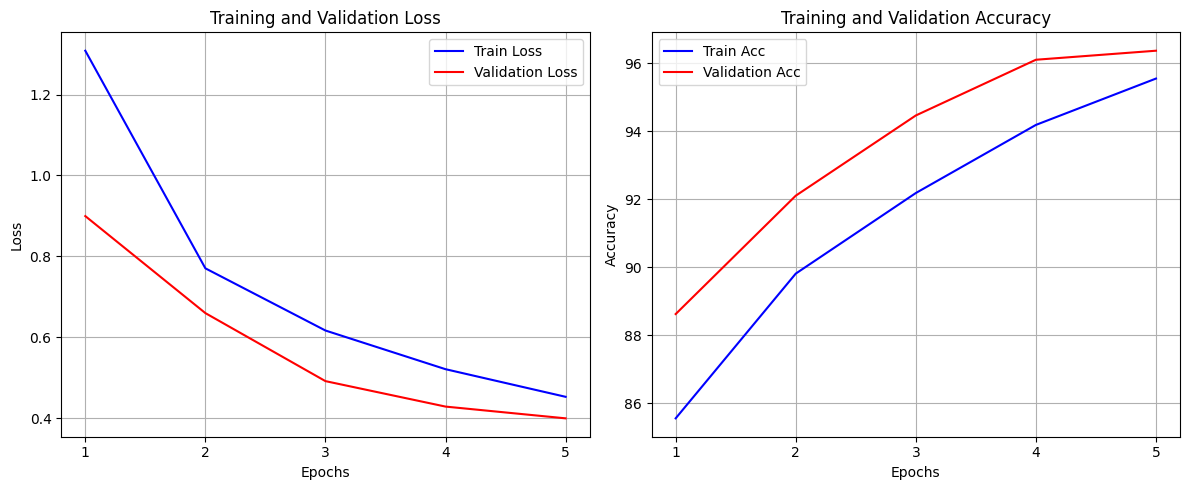

In [45]:
# 기존 Resnet50 모델
plot_history(history)

In [46]:
class DecodePredictions(nn.Module):
    """
    RetinaNet 예측을 실제 bounding boxes로 디코딩    
    Args:
        num_classes: 클래스 개수
        confidence_threshold: 신뢰도 임계값
        nms_iou_threshold: NMS IoU 임계값
        max_detections: 최대 탐지 개수
        box_variance: Anchor box 인코딩 시 사용된 분산
    """
    
    def __init__(
        self,
        num_classes=8,
        confidence_threshold=0.05,
        nms_iou_threshold=0.5,
        max_detections=100,
        box_variance=[0.1, 0.1, 0.2, 0.2]
    ):
        super(DecodePredictions, self).__init__()
        self.num_classes = num_classes
        self.confidence_threshold = confidence_threshold
        self.nms_iou_threshold = nms_iou_threshold
        self.max_detections = max_detections
        self._anchor_box = AnchorBox()
        self._box_variance = torch.tensor(box_variance, dtype=torch.float32)
    
    def _decode_box_predictions(self, anchor_boxes, box_predictions):
        """Anchor boxes와 예측값으로부터 실제 boxes 디코딩"""
        boxes = box_predictions * self._box_variance.to(box_predictions.device)
        boxes = torch.cat(
            [
                boxes[:, :, :2] * anchor_boxes[:, :, 2:] + anchor_boxes[:, :, :2],
                torch.exp(boxes[:, :, 2:]) * anchor_boxes[:, :, 2:]
            ],
            dim=-1
        )
        boxes_transformed = convert_to_corners(boxes)
        return boxes_transformed
    
    def forward(self, images, predictions):    
        """
        Args:
            images: (B, 3, H, W) 입력 이미지
            predictions: (B, num_anchors, 4 + num_classes) 모델 예측
        Returns:
            List of tuples (boxes, scores, classes) for each image in batch
        """
        image_shape = images.shape        
        anchor_boxes = self._anchor_box.get_anchors(image_shape[2], image_shape[3])
        anchor_boxes = anchor_boxes.to(predictions.device)
        
        box_predictions = predictions[:, :, :4]
        cls_predictions = torch.sigmoid(predictions[:, :, 4:])
        boxes = self._decode_box_predictions(anchor_boxes[None, ...], box_predictions)
        
        batch_results = []
        
        for i in range(boxes.shape[0]):
            selected_boxes = []
            selected_scores = []
            selected_classes = []
            
            for class_id in range(self.num_classes):
                class_scores = cls_predictions[i, :, class_id]
                mask = class_scores > self.confidence_threshold
                
                if mask.sum() == 0:
                    continue
                
                class_boxes = boxes[i, mask]
                class_scores_filtered = class_scores[mask]
                
                # NMS
                keep = nms(class_boxes, class_scores_filtered, self.nms_iou_threshold)
                
                selected_boxes.append(class_boxes[keep])
                selected_scores.append(class_scores_filtered[keep])
                selected_classes.append(torch.full((len(keep),), class_id, dtype=torch.int64))
            
            if len(selected_boxes) > 0:
                all_boxes = torch.cat(selected_boxes, dim=0)
                all_scores = torch.cat(selected_scores, dim=0)
                all_classes = torch.cat(selected_classes, dim=0)

                # 최대 탐지 개수 제한
                if len(all_boxes) > self.max_detections:
                    top_scores, top_indices = torch.topk(all_scores, self.max_detections)
                    all_boxes = all_boxes[top_indices]
                    all_scores = top_scores
                    all_classes = all_classes[top_indices]
            else:
                all_boxes = torch.empty((0, 4), device=boxes.device)
                all_scores = torch.empty((0,), device=boxes.device)
                all_classes = torch.empty((0,), dtype=torch.int64, device=boxes.device)
            
            batch_results.append((all_boxes, all_scores, all_classes))
        return batch_results

In [47]:
import torch
from PIL import Image, ImageDraw, ImageFont
import numpy as np
import os
from torchvision import transforms

# 클래스별 색상 매핑
CLASS_COLORS = {
    'Car': (255, 0, 0),           # 빨강
    'Van': (255, 128, 0),         # 주황
    'Truck': (255, 255, 0),       # 노랑
    'Pedestrian': (0, 255, 0),    # 초록
    'Person_sitting': (0, 255, 128),  # 연두
    'Cyclist': (0, 128, 255),     # 하늘색
    'Tram': (128, 0, 255),        # 보라
    'Misc': (255, 0, 255)         # 
}

def load_model(checkpoint_path='checkpoints/best.pth', num_classes=8, device='cuda'):
    """학습된 모델 로드"""
    device = torch.device(device if torch.cuda.is_available() else 'cpu')
    
    # backbone = get_resnet50_backbone(pretrained=False)
    # model = RetinaNet(num_classes=num_classes, backbone=backbone)
    backbone = get_regnet_backbone(pretrained=False)
    model = RetinaNetNew(num_classes=num_classes, backbone=backbone)

    # checkpoint_path = args.checkpoint_dir + "/best.pth"
    checkpoint_path = args.checkpoint
    
    try:
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"모델 로드 완료: {checkpoint_path}")
        print(f"   Epoch: {checkpoint.get('epoch', 'N/A')}, Loss: {checkpoint.get('loss', 'N/A'):.4f}")
    except FileNotFoundError:
        print(f"체크포인트를 찾을 수 없습니다: {checkpoint_path}")

    
    model = model.to(device)
    model.eval()
    
    decoder = DecodePredictions(
        num_classes=num_classes,
        confidence_threshold=0.3,
        nms_iou_threshold=0.5,
        max_detections=100
    )
    
    return model, decoder, device

In [49]:
# args.checkpoint_dir

In [50]:
def visualize_detection(
    image_path,
    checkpoint_path='checkpoints/best.pth',
    output_path=None,
    img_size=(384, 1280),
    show_scores=True,
    min_score=0.3,
    show_drive_assist=True
):
    """
    이미지에 탐지 결과 시각화
    Args:
        image_path: 입력 이미지 경로
        checkpoint_path: 모델 체크포인트
        output_path: 저장 경로 (None이면 화면에 표시)
        img_size: 모델 입력 크기
        show_scores: 점수 표시 여부
        show_drive_assist: 자율주행 보조 표시 여부
        min_score: 최소 표시 점수
    Returns:
        PIL Image with bounding boxes
    """
    # 클래스 이름
    class_names = ['Car', 'Van', 'Truck', 'Pedestrian', 
                  'Person_sitting', 'Cyclist', 'Tram', 'Misc']
    # 모델 로드
    # checkpoint_path = args.checkpoint_dir + "/best.pth"
    checkpoint_path = args.checkpoint
    model, decoder, device = load_model(checkpoint_path)
    # print(model)
    # 원본 이미지 로드
    image = Image.open(image_path).convert('RGB')
    original_size = image.size  # (width, height)
    # 스케일 계산
    scale_w = img_size[1] / original_size[0]
    scale_h = img_size[0] / original_size[1]
    
    # 전처리
    transform = transforms.Compose([
        transforms.Resize(img_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                           std=[0.229, 0.224, 0.225])
    ])
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    # 추론
    with torch.no_grad():
        predictions = model(image_tensor)
        decoded = decoder(image_tensor, predictions)
    
    boxes, scores, classes = decoded[0]
    boxes = boxes.cpu().numpy()
    scores = scores.cpu().numpy()
    classes = classes.cpu().numpy()
    
    # 원본 이미지에 그리기
    draw_image = image.copy()
    draw = ImageDraw.Draw(draw_image)
    
    # 폰트 설정 (한글 지원)
    try:
        font = ImageFont.truetype("malgun.ttf", 20)  # Windows
    except:
        font = ImageFont.load_default()
    
    detection_count = 0
    class_counts = {}
    
    # 각 탐지 결과 그리기
    for i, (box, score, cls) in enumerate(zip(boxes, scores, classes)):
        if score < min_score:
            continue
        detection_count += 1
        
        # 원본 좌표로 변환
        x1 = box[0] / scale_w
        y1 = box[1] / scale_h
        x2 = box[2] / scale_w
        y2 = box[3] / scale_h
        
        # 클래스 정보
        class_name = class_names[cls]
        color = CLASS_COLORS.get(class_name, (255, 255, 255))
        # 카운트
        class_counts[class_name] = class_counts.get(class_name, 0) + 1
        
        # 바운딩 박스 그리기
        draw.rectangle([x1, y1, x2, y2], outline=color, width=3)
        # 라벨 텍스트
        if show_scores:
            label = f"{class_name} {score:.2f}"
        else:
            label = class_name
        
        # 라벨 배경
        text_bbox = draw.textbbox((x1, y1 - 25), label, font=font)
        draw.rectangle(text_bbox, fill=color)
        draw.text((x1, y1 - 25), label, fill=(255, 255, 255), font=font)
    
    print(f"\n 탐지 완료!")
    print(f"   총 {detection_count}개 객체 탐지")
    if class_counts:
        print("   클래스별 개수:")
        for cls_name, count in sorted(class_counts.items()):
            print(f"     - {cls_name}: {count}")

    # 저장 또는 표시
    if output_path:
        os.makedirs(os.path.dirname(output_path) if os.path.dirname(output_path) else '.', exist_ok=True)
        draw_image.save(output_path)
        print(f"\n결과 저장: {output_path}")
    else:
        draw_image.show()
    
    return draw_image

In [51]:
import argparse
import glob
import random

parser = argparse.ArgumentParser(description='RetinaNet 추론 시각화')
parser.add_argument('--image', type=str, 
                   default=None,
                   help='이미지 경로 (지정하지 않으면 랜덤)')
parser.add_argument('--image_dir', type=str,
                   default=os.path.join(os.getcwd(), "data/Kitti/raw/testing/image_2"),
                   help='랜덤 선택할 이미지 디렉토리')
# parser.add_argument('--checkpoint', type=str, 
#                    default=os.path.join(os.getcwd(),'checkpoints/best.pth'),
#                    help='모델 체크포인트')
parser.add_argument('--checkpoint', type=str, 
                   default=os.path.join(os.getcwd(),'checkpoints/regnet/best.pth'),
                   help='모델 체크포인트')

parser.add_argument('--output', type=str, 
                   default='result.png',
                   help='결과 저장 경로')

args, unknown = parser.parse_known_args()

In [52]:
# result 폴더 생성
os.makedirs('result', exist_ok=True)

# 20번 반복
for i in range(20):
    # 이미지 경로 결정
    if args.image is None:
        # 랜덤 선택
        image_files = glob.glob(os.path.join(args.image_dir, '*.png'))
        image_files += glob.glob(os.path.join(args.image_dir, '*.jpg'))
        image_path = random.choice(image_files)
    # 출력 경로 설정
    output_path = f'result/result_{i+1:02d}.png'
    output_path = f'result/regnet/result_{i+1:02d}.png'    
    # 단일 이미지 처리
    visualize_detection(
        image_path,
        checkpoint_path=args.checkpoint,
        output_path=output_path,
        show_scores=True
    )

모델 로드 완료: /home/minkyujeong/work/DeepDive/ch2_obj_detection/checkpoints/regnet/best.pth
   Epoch: 4, Loss: 0.3993

 탐지 완료!
   총 10개 객체 탐지
   클래스별 개수:
     - Car: 8
     - Van: 2

결과 저장: result/regnet/result_01.png
모델 로드 완료: /home/minkyujeong/work/DeepDive/ch2_obj_detection/checkpoints/regnet/best.pth
   Epoch: 4, Loss: 0.3993

 탐지 완료!
   총 20개 객체 탐지
   클래스별 개수:
     - Car: 20

결과 저장: result/regnet/result_02.png
모델 로드 완료: /home/minkyujeong/work/DeepDive/ch2_obj_detection/checkpoints/regnet/best.pth
   Epoch: 4, Loss: 0.3993

 탐지 완료!
   총 2개 객체 탐지
   클래스별 개수:
     - Car: 2

결과 저장: result/regnet/result_03.png
모델 로드 완료: /home/minkyujeong/work/DeepDive/ch2_obj_detection/checkpoints/regnet/best.pth
   Epoch: 4, Loss: 0.3993

 탐지 완료!
   총 10개 객체 탐지
   클래스별 개수:
     - Car: 9
     - Van: 1

결과 저장: result/regnet/result_04.png
모델 로드 완료: /home/minkyujeong/work/DeepDive/ch2_obj_detection/checkpoints/regnet/best.pth
   Epoch: 4, Loss: 0.3993

 탐지 완료!
   총 2개 객체 탐지
   클래스별 개수:
     - Car: 2

결과 저장: r

In [ ]:
# args.checkpoint
# last_model_path = args.checkpoint.replace("best", "last")
# last_model_path

'/home/minkyujeong/work/DeepDive/ch2_obj_detection/checkpoints/last.pth'

In [53]:
def self_drive_assist(img_path, size_limit=300):
    """
    RetinaNet 추론 결과를 바탕으로 자율주행 보조 결정을 내림
    조건:
    - 사람(Pedestrian, Person_sitting, Cyclist)이 1명이라도 있으면 Stop
    - 차량(Car, Van, Truck, Tram) 중 하나라도 가로/세로가 300px 이상이면 Stop
    """
    # 1. 모델 설정 및 로드 (args.checkpoint 사용)
    class_names = ['Car', 'Van', 'Truck', 'Pedestrian', 'Person_sitting', 'Cyclist', 'Tram', 'Misc']
    model, decoder, device = load_model(args.checkpoint)
    # model, decoder, device = load_model(last_model_path)
    
    # 클래스 분류 정의 (인덱스 기준)
    person_indices = [3, 4, 5]  # Pedestrian, Person_sitting, Cyclist
    vehicle_indices = [0, 1, 2, 6]  # Car, Van, Truck, Tram
    
    # 2. 이미지 로드 및 전처리
    image = Image.open(img_path).convert('RGB')
    orig_w, orig_h = image.size
    img_size = (384, 1280) # 모델 입력 규격
    
    # 픽셀 좌표 복원을 위한 스케일 비율
    scale_w = img_size[1] / orig_w
    scale_h = img_size[0] / orig_h
    
    transform = transforms.Compose([
        transforms.Resize(img_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    # 3. 모델 추론 및 디코딩
    with torch.no_grad():        
        predictions = model(image_tensor)
        # DecodePredictions 클래스의 forward 호출
        decoded = decoder(image_tensor, predictions)
                
    
    # 첫 번째 배치 결과 가져오기
    boxes, scores, classes = decoded[0]
    boxes = boxes.cpu().numpy()
    scores = scores.cpu().numpy()
    classes = classes.cpu().numpy()
    
    # 4. 정지 조건 판단
    stop_flag = False
    
    for box, score, cls in zip(boxes, scores, classes):
        # DecodePredictions의 기본 threshold인 0.3을 넘긴 것만 판단
        if score < 0.3:
            continue
        # print(box, score, cls)
        # 원본 이미지의 픽셀 좌표로 변환
        x1, y1, x2, y2 = box[0]/scale_w, box[1]/scale_h, box[2]/scale_w, box[3]/scale_h
        width = x2 - x1
        height = y2 - y1
        cls_idx = int(cls)
        
        # 조건 1: 사람 감지
        if cls_idx in person_indices:
            print(f"  [STOP] 사람 감지: {class_names[cls_idx]} (Score: {score:.2f})")
            stop_flag = True
            break # 한 명이라도 있으면 즉시 정지
            
        # 조건 2: 대형 차량 감지
        if cls_idx in vehicle_indices:
            if width >= size_limit or height >= size_limit:
                print(f"  [STOP] 대형 차량 감지: {class_names[cls_idx]} (Size: {width:.1f}x{height:.1f})")
                stop_flag = True
                break
                
    return "Stop" if stop_flag else "Go"


In [54]:
# 실행
img_path = os.getcwd() + '/data/Kitti/raw/go_stop_test_data/stop_1.png'
print(f"최종 결과: {self_drive_assist(img_path)}")

모델 로드 완료: /home/minkyujeong/work/DeepDive/ch2_obj_detection/checkpoints/regnet/best.pth
   Epoch: 4, Loss: 0.3993
최종 결과: Go


In [55]:
import os

def test_system(func):
    work_dir = os.getcwd() +'/data/Kitti/raw/go_stop_test_data'
    score = 0
    test_set=[
        ("stop_1.png", "Stop"),
        ("stop_2.png", "Stop"),
        ("stop_3.png", "Stop"),
        ("stop_4.png", "Stop"),
        ("stop_5.png", "Stop"),
        ("go_1.png", "Go"),
        ("go_2.png", "Go"),
        ("go_3.png", "Go"),
        ("go_4.png", "Go"),
        ("go_5.png", "Go"),
    ]

    for image_file, answer in test_set:
        image_path = work_dir + '/' + image_file
        pred = func(image_path)
        if pred == answer:
            score += 10
    print(f"{score}점입니다.")

test_system(self_drive_assist)

모델 로드 완료: /home/minkyujeong/work/DeepDive/ch2_obj_detection/checkpoints/regnet/best.pth
   Epoch: 4, Loss: 0.3993
모델 로드 완료: /home/minkyujeong/work/DeepDive/ch2_obj_detection/checkpoints/regnet/best.pth
   Epoch: 4, Loss: 0.3993
모델 로드 완료: /home/minkyujeong/work/DeepDive/ch2_obj_detection/checkpoints/regnet/best.pth
   Epoch: 4, Loss: 0.3993
모델 로드 완료: /home/minkyujeong/work/DeepDive/ch2_obj_detection/checkpoints/regnet/best.pth
   Epoch: 4, Loss: 0.3993
  [STOP] 대형 차량 감지: Van (Size: 292.9x340.1)
모델 로드 완료: /home/minkyujeong/work/DeepDive/ch2_obj_detection/checkpoints/regnet/best.pth
   Epoch: 4, Loss: 0.3993
모델 로드 완료: /home/minkyujeong/work/DeepDive/ch2_obj_detection/checkpoints/regnet/best.pth
   Epoch: 4, Loss: 0.3993
모델 로드 완료: /home/minkyujeong/work/DeepDive/ch2_obj_detection/checkpoints/regnet/best.pth
   Epoch: 4, Loss: 0.3993
모델 로드 완료: /home/minkyujeong/work/DeepDive/ch2_obj_detection/checkpoints/regnet/best.pth
   Epoch: 4, Loss: 0.3993
모델 로드 완료: /home/minkyujeong/work/DeepDive/ch2